In [1]:
import pandas as pd

In [32]:
from tqdm import tqdm

In [50]:
import matplotlib.pyplot as plt

In [75]:
import numpy as np

In [3]:
Data = pd.read_csv('Data/FeatureEngineered_Data.csv')

In [4]:
Data.head(20)

,provinceid,dguid,datestamp,noc_groupingid,employment,year,Key,datestampe,ER_t_1,ER_t_2,...,quarter,week,dayofyear_sin,dayofyear_cos,month_sin,month_cos,quarter_sin,quarter_cos,week_sin,week_cos
0,10,2021A000210,2000-01-01,1,7.0,2000,"(10, 1)",2000-01-01,NaN,NaN,...,1,52,0.017213,0.999852,5.000000e-01,8.660254e-01,1.000000e+00,6.123234e-17,6.432491e-16,1.000000e+00
1,10,2021A000210,2000-02-01,1,8.2,2000,"(10, 1)",2000-02-01,7.0,NaN,...,1,5,0.523416,0.852078,8.660254e-01,5.000000e-01,1.000000e+00,6.123234e-17,5.680647e-01,8.229839e-01
2,10,2021A000210,2000-03-01,1,7.1,2000,"(10, 1)",2000-03-01,8.2,7.0,...,1,9,0.867456,0.497513,1.000000e+00,6.123234e-17,1.000000e+00,6.123234e-17,8.854560e-01,4.647232e-01
3,10,2021A000210,2000-04-01,1,7.6,2000,"(10, 1)",2000-04-01,7.1,8.2,...,2,13,0.999917,-0.012910,8.660254e-01,-5.000000e-01,1.224647e-16,-1.000000e+00,1.000000e+00,-1.608123e-16
4,10,2021A000210,2000-05-01,1,6.9,2000,"(10, 1)",2000-05-01,7.6,7.1,...,2,18,0.863142,-0.504961,5.000000e-01,-8.660254e-01,1.224647e-16,-1.000000e+00,8.229839e-01,-5.680647e-01
5,10,2021A000210,2000-06-01,1,7.8,2000,"(10, 1)",2000-06-01,6.9,7.6,...,2,22,0.486273,-0.873807,1.224647e-16,-1.000000e+00,1.224647e-16,-1.000000e+00,4.647232e-01,-8.854560e-01
6,10,2021A000210,2000-07-01,1,7.3,2000,"(10, 1)",2000-07-01,7.8,6.9,...,3,26,-0.008607,-0.999963,-5.000000e-01,-8.660254e-01,-1.000000e+00,-1.836970e-16,-3.216245e-16,-1.000000e+00
7,10,2021A000210,2000-08-01,1,7.0,2000,"(10, 1)",2000-08-01,7.3,7.8,...,3,31,-0.516062,-0.856551,-8.660254e-01,-5.000000e-01,-1.000000e+00,-1.836970e-16,-5.680647e-01,-8.229839e-01
8,10,2021A000210,2000-09-01,1,7.9,2000,"(10, 1)",2000-09-01,7.0,7.3,...,3,35,-0.880012,-0.474951,-1.000000e+00,-1.836970e-16,-1.000000e+00,-1.836970e-16,-8.854560e-01,-4.647232e-01
9,10,2021A000210,2000-10-01,1,8.4,2000,"(10, 1)",2000-10-01,7.9,7.0,...,4,39,-0.999769,0.021516,-8.660254e-01,5.000000e-01,-2.449294e-16,1.000000e+00,-1.000000e+00,-1.836970e-16


In [5]:
print(f"Data Columns =>\n{list(Data.columns)}")

Data Columns =>
['provinceid', 'dguid', 'datestamp', 'noc_groupingid', 'employment', 'year', 'Key', 'datestampe', 'ER_t_1', 'ER_t_2', 'ER_t_3', 'ER_t_4', 'ER_t_5', 'ER_t_6', 'ER_t_7', 'ER_t_8', 'ER_t_9', 'ER_t_10', 'ER_t_11', 'ER_t_12', 'ER_t_1_rollingmean', 'ER_t_1_rollingstd', 'ER_t_2_rollingmean', 'ER_t_2_rollingstd', 'ER_t_3_rollingmean', 'ER_t_3_rollingstd', 'ER_t_4_rollingmean', 'ER_t_4_rollingstd', 'ER_t_5_rollingmean', 'ER_t_5_rollingstd', 'ER_t_6_rollingmean', 'ER_t_6_rollingstd', 'ER_t_7_rollingmean', 'ER_t_7_rollingstd', 'ER_t_8_rollingmean', 'ER_t_8_rollingstd', 'ER_t_9_rollingmean', 'ER_t_9_rollingstd', 'ER_t_10_rollingmean', 'ER_t_10_rollingstd', 'ER_t_11_rollingmean', 'ER_t_11_rollingstd', 'ER_t_12_rollingmean', 'ER_t_12_rollingstd', 'dayofyear', 'month', 'quarter', 'week', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos', 'week_sin', 'week_cos']


In [6]:
Data.columns.tolist()

['provinceid',
 'dguid',
 'datestamp',
 'noc_groupingid',
 'employment',
 'year',
 'Key',
 'datestampe',
 'ER_t_1',
 'ER_t_2',
 'ER_t_3',
 'ER_t_4',
 'ER_t_5',
 'ER_t_6',
 'ER_t_7',
 'ER_t_8',
 'ER_t_9',
 'ER_t_10',
 'ER_t_11',
 'ER_t_12',
 'ER_t_1_rollingmean',
 'ER_t_1_rollingstd',
 'ER_t_2_rollingmean',
 'ER_t_2_rollingstd',
 'ER_t_3_rollingmean',
 'ER_t_3_rollingstd',
 'ER_t_4_rollingmean',
 'ER_t_4_rollingstd',
 'ER_t_5_rollingmean',
 'ER_t_5_rollingstd',
 'ER_t_6_rollingmean',
 'ER_t_6_rollingstd',
 'ER_t_7_rollingmean',
 'ER_t_7_rollingstd',
 'ER_t_8_rollingmean',
 'ER_t_8_rollingstd',
 'ER_t_9_rollingmean',
 'ER_t_9_rollingstd',
 'ER_t_10_rollingmean',
 'ER_t_10_rollingstd',
 'ER_t_11_rollingmean',
 'ER_t_11_rollingstd',
 'ER_t_12_rollingmean',
 'ER_t_12_rollingstd',
 'dayofyear',
 'month',
 'quarter',
 'week',
 'dayofyear_sin',
 'dayofyear_cos',
 'month_sin',
 'month_cos',
 'quarter_sin',
 'quarter_cos',
 'week_sin',
 'week_cos']

In [7]:
lags_and_indicators = [ 'ER_t_1',
 'ER_t_2',
 'ER_t_3',
 'ER_t_4',
 'ER_t_5',
 'ER_t_6',
 'ER_t_7',
 'ER_t_8',
 'ER_t_9',
 'ER_t_10',
 'ER_t_11',
 'ER_t_12',
 'ER_t_1_rollingmean',
 'ER_t_1_rollingstd',
 'ER_t_2_rollingmean',
 'ER_t_2_rollingstd',
 'ER_t_3_rollingmean',
 'ER_t_3_rollingstd',
 'ER_t_4_rollingmean',
 'ER_t_4_rollingstd',
 'ER_t_5_rollingmean',
 'ER_t_5_rollingstd',
 'ER_t_6_rollingmean',
 'ER_t_6_rollingstd',
 'ER_t_7_rollingmean',
 'ER_t_7_rollingstd',
 'ER_t_8_rollingmean',
 'ER_t_8_rollingstd',
 'ER_t_9_rollingmean',
 'ER_t_9_rollingstd',
 'ER_t_10_rollingmean',
 'ER_t_10_rollingstd',
 'ER_t_11_rollingmean',
 'ER_t_11_rollingstd',
 'ER_t_12_rollingmean',
 'ER_t_12_rollingstd']

exog_variables = [
 'dayofyear_sin',
 'dayofyear_cos',
 'month_sin',
 'month_cos',
 'quarter_sin',
 'quarter_cos',
 'week_sin',
 'week_cos'
]

categoricals = [
 'provinceid',
 'dayofyear',
 'month',
 'quarter',
 'week'
]

target = ['employment']


In [8]:
null_counts = Data.groupby('year')[lags_and_indicators].apply(lambda x: x.isna().sum())
null_counts

,ER_t_1,ER_t_2,ER_t_3,ER_t_4,ER_t_5,ER_t_6,ER_t_7,ER_t_8,ER_t_9,ER_t_10,...,ER_t_8_rollingmean,ER_t_8_rollingstd,ER_t_9_rollingmean,ER_t_9_rollingstd,ER_t_10_rollingmean,ER_t_10_rollingstd,ER_t_11_rollingmean,ER_t_11_rollingstd,ER_t_12_rollingmean,ER_t_12_rollingstd
year,,,,,,,,,,,,,,,,,,,,,
2000,574,1148,1722,2296,2870,3444,4018,4592,5166,5740,...,6313,6313,6886,6886,6886,6886,6886,6886,6886,6886
2001,0,0,0,0,0,0,0,0,0,0,...,1,1,2,2,576,576,1150,1150,1724,1724
2002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2006,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2007,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2008,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
#Training should start at 2002

In [11]:
train = Data[(Data['year']>=2002) & (Data['year']<2025)] #Includes intented training and validation periods. 
train.head(50)

,provinceid,dguid,datestamp,noc_groupingid,employment,year,Key,datestampe,ER_t_1,ER_t_2,...,quarter,week,dayofyear_sin,dayofyear_cos,month_sin,month_cos,quarter_sin,quarter_cos,week_sin,week_cos
24,10,2021A000210,2002-01-01,1,9.5,2002,"(10, 1)",2002-01-01,9.0,7.8,...,1,1,0.017213,0.999852,5.000000e-01,8.660254e-01,1.000000e+00,6.123234e-17,1.205367e-01,9.927089e-01
25,10,2021A000210,2002-02-01,1,9.3,2002,"(10, 1)",2002-02-01,9.5,9.0,...,1,5,0.523416,0.852078,8.660254e-01,5.000000e-01,1.000000e+00,6.123234e-17,5.680647e-01,8.229839e-01
26,10,2021A000210,2002-03-01,1,8.1,2002,"(10, 1)",2002-03-01,9.3,9.5,...,1,9,0.858764,0.512371,1.000000e+00,6.123234e-17,1.000000e+00,6.123234e-17,8.854560e-01,4.647232e-01
27,10,2021A000210,2002-04-01,1,8.3,2002,"(10, 1)",2002-04-01,8.1,9.3,...,2,14,0.999991,0.004304,8.660254e-01,-5.000000e-01,1.224647e-16,-1.000000e+00,9.927089e-01,-1.205367e-01
28,10,2021A000210,2002-05-01,1,9.0,2002,"(10, 1)",2002-05-01,8.3,8.1,...,2,18,0.871706,-0.490029,5.000000e-01,-8.660254e-01,1.224647e-16,-1.000000e+00,8.229839e-01,-5.680647e-01
29,10,2021A000210,2002-06-01,1,8.7,2002,"(10, 1)",2002-06-01,9.0,8.3,...,2,22,0.501242,-0.865307,1.224647e-16,-1.000000e+00,1.224647e-16,-1.000000e+00,4.647232e-01,-8.854560e-01
30,10,2021A000210,2002-07-01,1,8.2,2002,"(10, 1)",2002-07-01,8.7,9.0,...,3,27,0.008607,-0.999963,-5.000000e-01,-8.660254e-01,-1.000000e+00,-1.836970e-16,-1.205367e-01,-9.927089e-01
31,10,2021A000210,2002-08-01,1,8.9,2002,"(10, 1)",2002-08-01,8.2,8.7,...,3,31,-0.501242,-0.865307,-8.660254e-01,-5.000000e-01,-1.000000e+00,-1.836970e-16,-5.680647e-01,-8.229839e-01
32,10,2021A000210,2002-09-01,1,9.0,2002,"(10, 1)",2002-09-01,8.9,8.2,...,3,35,-0.871706,-0.490029,-1.000000e+00,-1.836970e-16,-1.000000e+00,-1.836970e-16,-8.854560e-01,-4.647232e-01
33,10,2021A000210,2002-10-01,1,8.2,2002,"(10, 1)",2002-10-01,9.0,8.9,...,4,40,-0.999991,0.004304,-8.660254e-01,5.000000e-01,-2.449294e-16,1.000000e+00,-9.927089e-01,1.205367e-01


Filter Methods -- Start -- Testing Correlations 

In [42]:
Keys = train['Key'].unique().tolist()


In [44]:
def Generate_Correlations(Sample):
    Corrs = Sample.corr()['employment']
    return Corrs

def Append_Corrs(Corrs, Corr_List, Feats, Key):
    corr_dict = {}
    corr_dict['Key'] = Key

    for f in Feats:
        corr_dict[f] = Corrs[f]
    
    Corr_List.append(corr_dict)
    
def Store_Correlations(Keys, train):
    Corrs_List = []

    for key in tqdm(Keys, desc='Processing NOC Groups', unit='NOC Grouping ID'):
        Sample = train[train['Key']==key][lags_and_indicators + target]

        Corrs = Generate_Correlations(Sample=Sample)
        Append_Corrs(Corrs=Corrs, Corr_List=Corrs_List, Feats=lags_and_indicators, Key=key)
    
    df_Corrs = pd.DataFrame(Corrs_List)
    return df_Corrs

In [45]:
df_Corrs = Store_Correlations(Keys=Keys, train=train)

Processing NOC Groups: 100%|██████████| 574/574 [00:03<00:00, 182.32NOC Grouping ID/s]


In [55]:
lags = ['ER_t_1',
 'ER_t_2',
 'ER_t_3',
 'ER_t_4',
 'ER_t_5',
 'ER_t_6',
 'ER_t_7',
 'ER_t_8',
 'ER_t_9',
 'ER_t_10',
 'ER_t_11',
 'ER_t_12',]

In [58]:
indicators = [
 'ER_t_1_rollingmean',
 'ER_t_1_rollingstd',
 'ER_t_2_rollingmean',
 'ER_t_2_rollingstd',
 'ER_t_3_rollingmean',
 'ER_t_3_rollingstd',
 'ER_t_4_rollingmean',
 'ER_t_4_rollingstd',
 'ER_t_5_rollingmean',
 'ER_t_5_rollingstd',
 'ER_t_6_rollingmean',
 'ER_t_6_rollingstd',
 'ER_t_7_rollingmean',
 'ER_t_7_rollingstd',
 'ER_t_8_rollingmean',
 'ER_t_8_rollingstd',
 'ER_t_9_rollingmean',
 'ER_t_9_rollingstd',
 'ER_t_10_rollingmean',
 'ER_t_10_rollingstd',
 'ER_t_11_rollingmean',
 'ER_t_11_rollingstd',
 'ER_t_12_rollingmean',
 'ER_t_12_rollingstd'
]

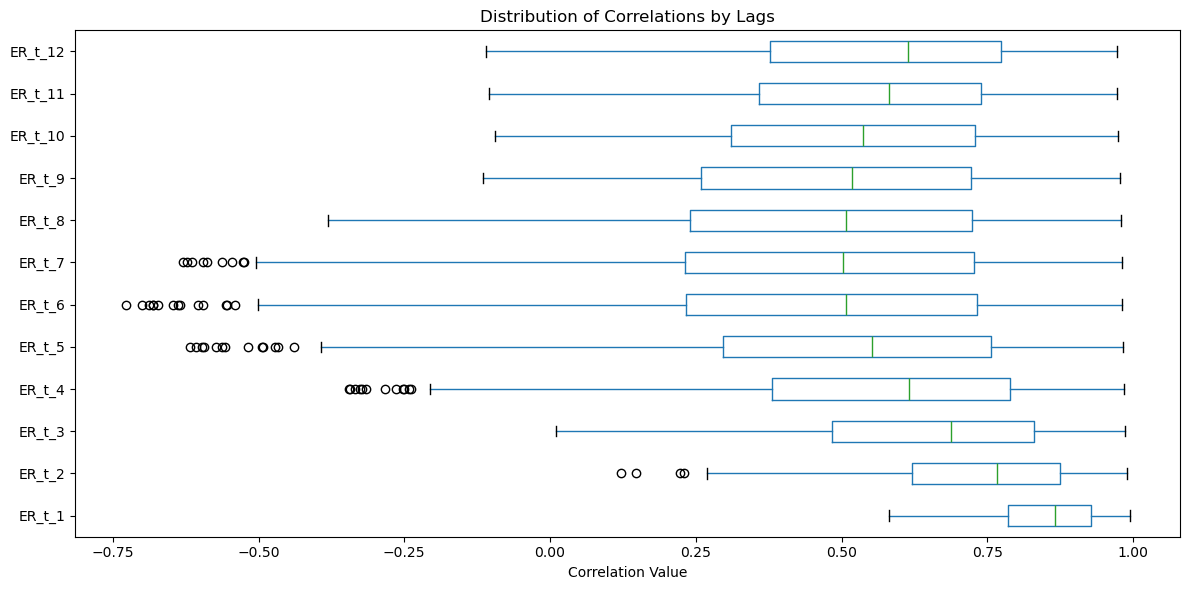

In [57]:
plt.figure(figsize=(12, 6))
df_Corrs[lags].boxplot(
    vert=False,
    grid=False,
    showfliers=True
)

plt.title("Distribution of Correlations by Lags")
plt.xlabel("Correlation Value")
plt.tight_layout()
plt.show()

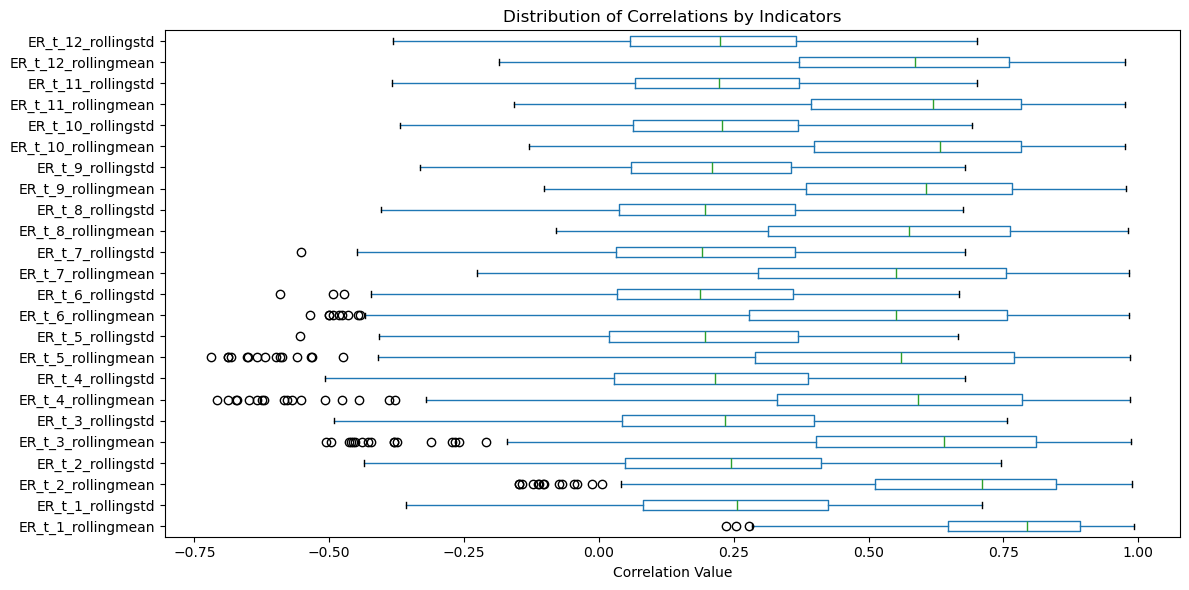

In [59]:
plt.figure(figsize=(12, 6))
df_Corrs[indicators].boxplot(
    vert=False,
    grid=False,
    showfliers=True
)

plt.title("Distribution of Correlations by Indicators")
plt.xlabel("Correlation Value")
plt.tight_layout()
plt.show()

Filter Methods -- End -- Outcomes 

In [ ]:
'''
Per the box plot distribution it seems that Short Terms lags (1, 2, and 3) along with long term lags (10, 11, 12) provide
best general performance -- in terms of explaining the variance in the target variable. 

As such the indicators seem to show that moving averages of the Short Term and Long Terms lags have higher correlations 
with the target. Moving standard deviations do not seem to have much to offer. 

'''

Wrapper Methods -- Start -- Testing Recursive Feature Elimination with XGB

In [63]:
from xgboost import XGBRegressor
from sklearn.feature_selection import RFE

In [ ]:
def Initialize_Models():
    #XG Boost Model with Conservative hyper params: 
    #   -n_estimators => build 200 trees 
    #   -max_depth => model only 4 levels of feature interaction 
    #   -learing rate => learn relatively slow 
    xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    )

    #Selecting the best 10 features. 
    rfe = RFE(
    estimator=xgb,
    n_features_to_select=10,
    step=1
    )

    return rfe

def Run_Elimination(rfe, X, Y):
    rfe.fit(X, Y)
    return rfe

def Get_Sets(Key):
    train_reduced = train[train['Key']==Key][lags_and_indicators + categoricals + exog_variables + target]
    X = train_reduced[lags_and_indicators + categoricals + exog_variables]
    Y = train_reduced[target]

    return X, Y

def Get_Gain_Importance(rfe, X, Key):
    xgb_importance_full = np.zeros(X.shape[1])

    xgb_importance_full[rfe.support_] = rfe.estimator_.feature_importances_

    summary = pd.DataFrame({
    'Key': Key,
    'feature': X.columns,
    'selected': rfe.support_,
    'rfe_ranking': rfe.ranking_,
    'xgb_gain_importance': xgb_importance_full
    }).sort_values(
    ['selected', 'xgb_gain_importance'],
    ascending=[False, False]
    )

    return summary



def Run_Wrapper_Method(Keys=Keys):

    Feat_Importance_Frame = []
    for Key in tqdm(Keys, desc='Processing Keys of Wrapper Method', unit='Key'):
        X, Y = Get_Sets(Key=Key)

        rfe = Initialize_Models()
        rfe = Run_Elimination(rfe=rfe, X=X, Y=Y)
        summary = Get_Gain_Importance(rfe=rfe, X=X, Key=Key)
    
        Feat_Importance_Frame.append(summary)
    
    df_Feature_Gain_Importance = pd.concat(Feat_Importance_Frame, axis=0)
    return df_Feature_Gain_Importance

        

In [84]:
df_Feature_Gain_Importance = Run_Wrapper_Method(Keys=Keys)

Processing Keys of Wrapper Method: 100%|██████████| 574/574 [34:32<00:00,  3.61s/Key]


In [86]:
df_Feature_Gain_Importance = df_Feature_Gain_Importance[df_Feature_Gain_Importance['selected']==True]
df_Feature_Gain_Importance

,Key,feature,selected,rfe_ranking,xgb_gain_importance
0,"(10, 1)",ER_t_1,True,1,0.325981
12,"(10, 1)",ER_t_1_rollingmean,True,1,0.317084
1,"(10, 1)",ER_t_2,True,1,0.125376
40,"(10, 1)",week,True,1,0.036234
42,"(10, 1)",dayofyear_cos,True,1,0.034948
...,...,...,...,...,...
35,"(59, 60)",ER_t_12_rollingstd,True,1,0.042151
24,"(59, 60)",ER_t_7_rollingmean,True,1,0.042112
48,"(59, 60)",week_cos,True,1,0.041564
29,"(59, 60)",ER_t_9_rollingstd,True,1,0.039477


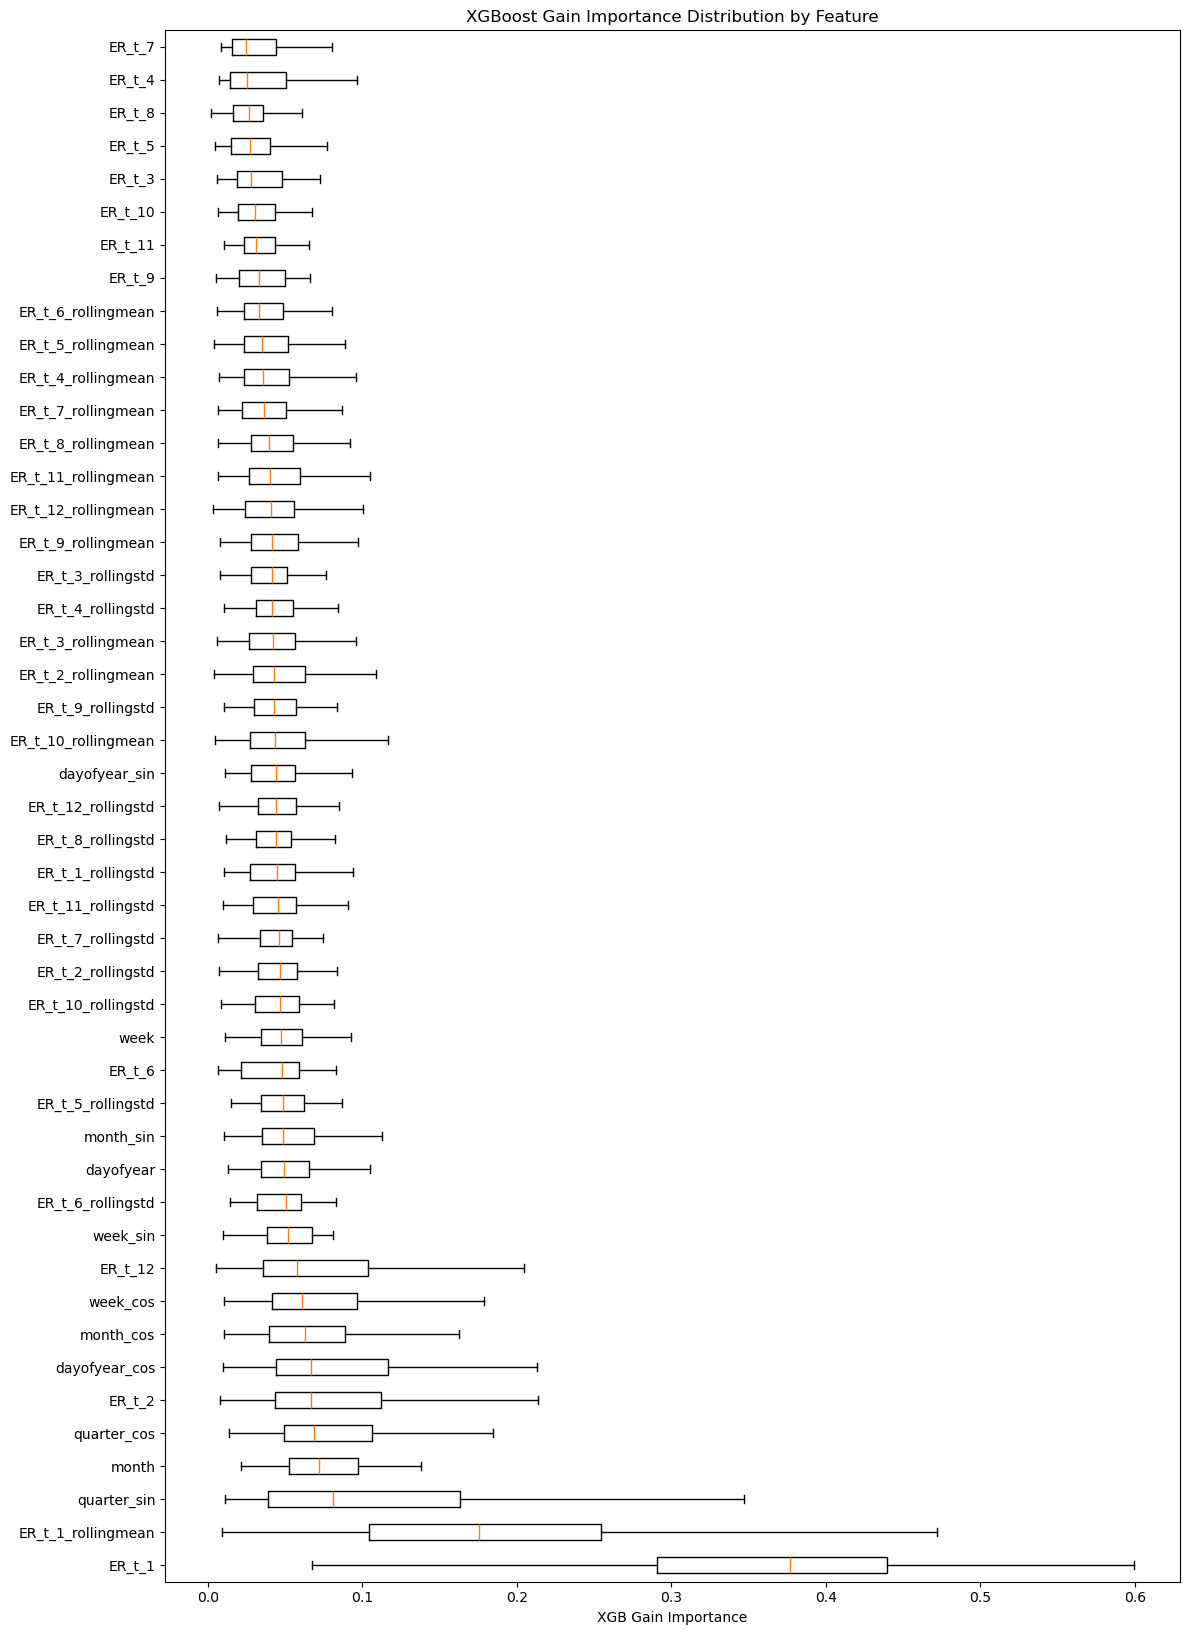

In [93]:
#Sorting Gain Importance based on median (middle of boxplot)
order = (
    df_Feature_Gain_Importance
    .groupby('feature')['xgb_gain_importance']
    .median()
    .sort_values(ascending=False)
    .index
)

#Creating a list of with the sorted distribution
data = [
    df_Feature_Gain_Importance.loc[
        df_Feature_Gain_Importance['feature'] == feature,
        'xgb_gain_importance'
    ]
    for feature in order
]

#ploting the data
plt.figure(figsize=(12, 0.35 * len(order))) 
plt.boxplot(data, vert=False, showfliers=False)

plt.yticks(
    ticks=range(1, len(order) + 1),
    labels=order
)

plt.xlabel('XGB Gain Importance')
plt.title('XGBoost Gain Importance Distribution by Feature')
plt.tight_layout()
plt.show()

Wrapper Methods -- End -- Outcomes 

In [ ]:
'''
Based on the Wrapper Method boxplot lag 1 has generally the highest gain importance, followed by the exogenous variables and 
the 2nd and 12th lag along with the rolling mean of lag 1

'''

Ensemble Methods -- Start -- Testing Features from Filter and Wrapper Methods with Ensemble Methods 

In [94]:
lags_and_indicators

['ER_t_1',
 'ER_t_2',
 'ER_t_3',
 'ER_t_4',
 'ER_t_5',
 'ER_t_6',
 'ER_t_7',
 'ER_t_8',
 'ER_t_9',
 'ER_t_10',
 'ER_t_11',
 'ER_t_12',
 'ER_t_1_rollingmean',
 'ER_t_1_rollingstd',
 'ER_t_2_rollingmean',
 'ER_t_2_rollingstd',
 'ER_t_3_rollingmean',
 'ER_t_3_rollingstd',
 'ER_t_4_rollingmean',
 'ER_t_4_rollingstd',
 'ER_t_5_rollingmean',
 'ER_t_5_rollingstd',
 'ER_t_6_rollingmean',
 'ER_t_6_rollingstd',
 'ER_t_7_rollingmean',
 'ER_t_7_rollingstd',
 'ER_t_8_rollingmean',
 'ER_t_8_rollingstd',
 'ER_t_9_rollingmean',
 'ER_t_9_rollingstd',
 'ER_t_10_rollingmean',
 'ER_t_10_rollingstd',
 'ER_t_11_rollingmean',
 'ER_t_11_rollingstd',
 'ER_t_12_rollingmean',
 'ER_t_12_rollingstd']

In [98]:
reduced_lags = ['ER_t_1',
 'ER_t_2',
 'ER_t_3', 'ER_t_10',
 'ER_t_11',
 'ER_t_12']

reduced_indicators = [
     'ER_t_1_rollingmean',
     'ER_t_2_rollingmean',
     'ER_t_3_rollingmean',
     'ER_t_4_rollingmean',
     'ER_t_10_rollingmean',
     'ER_t_11_rollingmean',
     'ER_t_12_rollingmean',
]





In [ ]:
def Initialize_Models():
    #XG Boost Model with Conservative hyper params: 
    #   -n_estimators => build 200 trees 
    #   -max_depth => model only 4 levels of feature interaction 
    #   -learing rate => learn relatively slow 
    xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    )

    return xgb

def Fit_Model(xgb, X, Y):
    xgb.fit(X,Y)
    booster = xgb.get_booster()
    gain = booster.get_score(importance_type='gain')
    return gain

def Get_Sets(Key):
    train_reduced = train[train['Key']==Key][reduced_lags + reduced_indicators + exog_variables + target]
    X = train_reduced[reduced_lags + reduced_indicators + exog_variables]
    Y = train_reduced[target]

    return X, Y

def Get_Gain_Importance(gain, X, Key):
   


    xgb_importance_full = np.zeros(X.shape[1])
    gain_series = pd.Series(gain, dtype=float)


    if gain_series.index.str.startswith("f").all():
        gain_series.index = [
            X.columns[int(f[1:])] for f in gain_series.index
        ]

    
    gain_series = gain_series.reindex(X.columns).fillna(0)

    xgb_importance_full[:] = gain_series.values

    summary = pd.DataFrame({
        "Key": Key,
        "feature": X.columns,
        "selected": xgb_importance_full > 0,
        "xgb_gain_importance": xgb_importance_full
    }).sort_values(
        ["selected", "xgb_gain_importance"],
        ascending=[False, False]
    )

    # Optional ranking (gain-based)
    summary["gain_rank"] = summary["xgb_gain_importance"].rank(
        ascending=False,
        method="dense"
    )

    return summary
    



def Run_Ensemble_Method(Keys=Keys):

    Feat_Importance_Frame = []
    for Key in tqdm(Keys, desc='Processing Keys for Ensemble Method', unit='Key'):
        X, Y = Get_Sets(Key=Key)

        xgb = Initialize_Models()
        gain = Fit_Model(xgb=xgb, X=X, Y=Y)
        summary = Get_Gain_Importance(gain=gain, X=X, Key=Key)
    
        Feat_Importance_Frame.append(summary)
    
    df_Feature_Gain_Importance = pd.concat(Feat_Importance_Frame, axis=0)
    return df_Feature_Gain_Importance

        
    

In [101]:
df_Feature_Gain_Importance_Ensemble = Run_Ensemble_Method()

Processing Keys for Ensemble Method: 100%|██████████| 574/574 [01:15<00:00,  7.61Key/s]


In [102]:
df_Feature_Gain_Importance_Ensemble = df_Feature_Gain_Importance_Ensemble[df_Feature_Gain_Importance_Ensemble['selected']==True]
df_Feature_Gain_Importance_Ensemble

,Key,feature,selected,xgb_gain_importance,gain_rank
0,"(10, 1)",ER_t_1,True,10.073613,1.0
6,"(10, 1)",ER_t_1_rollingmean,True,6.135417,2.0
7,"(10, 1)",ER_t_2_rollingmean,True,3.747248,3.0
1,"(10, 1)",ER_t_2,True,2.886399,4.0
15,"(10, 1)",month_sin,True,1.218775,5.0
...,...,...,...,...,...
12,"(59, 60)",ER_t_12_rollingmean,True,3.150693,17.0
3,"(59, 60)",ER_t_10,True,2.988357,18.0
4,"(59, 60)",ER_t_11,True,2.865183,19.0
5,"(59, 60)",ER_t_12,True,2.789154,20.0


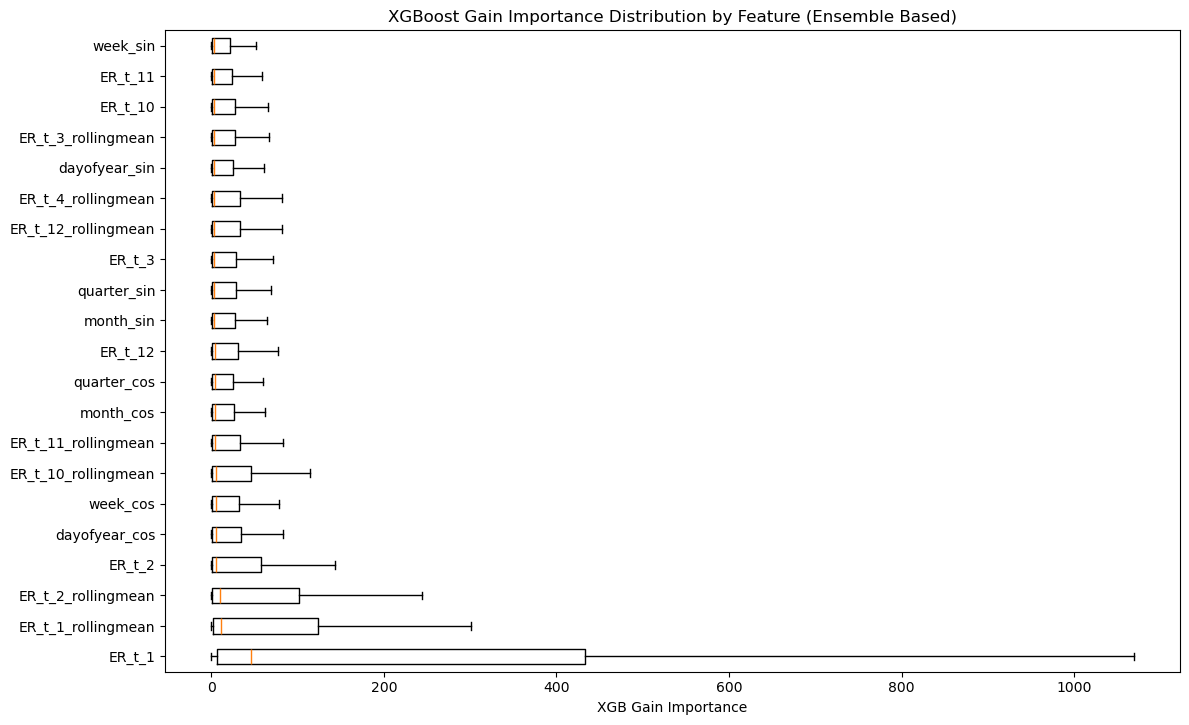

In [103]:
#Sorting Gain Importance based on median (middle of boxplot)
order = (
    df_Feature_Gain_Importance_Ensemble
    .groupby('feature')['xgb_gain_importance']
    .median()
    .sort_values(ascending=False)
    .index
)

#Creating a list of with the sorted distribution
data = [
    df_Feature_Gain_Importance_Ensemble.loc[
        df_Feature_Gain_Importance_Ensemble['feature'] == feature,
        'xgb_gain_importance'
    ]
    for feature in order
]

#ploting the data
plt.figure(figsize=(12, 0.35 * len(order))) 
plt.boxplot(data, vert=False, showfliers=False)

plt.yticks(
    ticks=range(1, len(order) + 1),
    labels=order
)

plt.xlabel('XGB Gain Importance')
plt.title('XGBoost Gain Importance Distribution by Feature (Ensemble Based)')
plt.tight_layout()
plt.show()

Ensemble Methods -- End -- Outcomes 

In [ ]:
'''
Based on the Ensemble Results it would seem that Lag 1 is the most dominant feature, followed by the rolling means of lag 1 and 2. 
Furthermore, Lag 12 seems to have relatively high gain when compared to Lag 3 and Lag 10. However, we are looking at distribution of 
gain, therefore it might be pertitent to include lags 1, 2, 3, 10, 11, 12 along with rolling mean indicators for 1, 2, 10, 11. 
'''